In [23]:
import torch
import torch.nn as nn
from torchvision import datasets,transforms
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader


In [24]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [25]:
# loading the data
batch_size = 64

transform = transforms.Compose([transforms.ToTensor()])

train_data = datasets.MNIST(root='./data',train=True,download=True,transform=transform)

train_loader = DataLoader(dataset = train_data , batch_size = 64, shuffle =True)


In [26]:
# Class AUtoEncoder

class AutoEncoder(nn.Module):
  def __init__(self, input_dim=784, hidden_dim=256, latent_dim=32):
    super().__init__()

    self.encoder = nn.Sequential(
        nn.Linear(input_dim, hidden_dim),
        nn.ReLU(),
        nn.Linear(hidden_dim, latent_dim)
    )

    self.decoder = nn.Sequential(
        nn.Linear(latent_dim, hidden_dim),
        nn.ReLU(),
        nn.Linear(hidden_dim, input_dim),
        nn.Sigmoid()
    )

  def forward (self,x):
      z = self.encoder(x)
      x_hat = self.decoder(z)

      return x_hat

In [27]:
model = AutoEncoder().to(device)
optimizer = optim.Adam(model.parameters(),lr=0.001)
criterion = nn.MSELoss()

In [28]:
epochs = 10
model.train()

for epoch in range(epochs):
    total_loss = 0

    for x, _ in train_loader:
        x = x.view(-1, 784).to(device)

        optimizer.zero_grad()

        x_hat = model(x)
        loss = criterion(x_hat, x)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f'Epoch [{epoch+1}/{epochs}] | Loss: {avg_loss:.4f}')

Epoch [1/10] | Loss: 0.0297
Epoch [2/10] | Loss: 0.0116
Epoch [3/10] | Loss: 0.0090
Epoch [4/10] | Loss: 0.0078
Epoch [5/10] | Loss: 0.0072
Epoch [6/10] | Loss: 0.0067
Epoch [7/10] | Loss: 0.0064
Epoch [8/10] | Loss: 0.0061
Epoch [9/10] | Loss: 0.0059
Epoch [10/10] | Loss: 0.0058


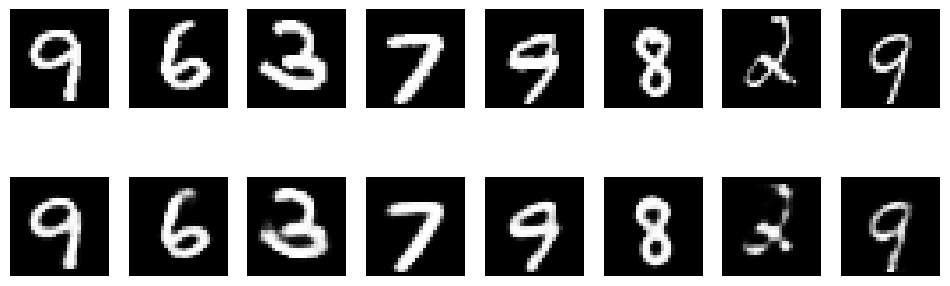

In [29]:
model.eval()

with torch.no_grad():
  x,_ = next(iter(train_loader))
  x = x.view(-1,784).to(device)
  x_hat = model(x)

x = x.cpu().view(-1,1,28,28)
x_hat = x_hat.cpu().view(-1,1,28,28)

n = 8
plt.figure(figsize=(12, 4))

for i in range(n):
    # original
    plt.subplot(2, n, i + 1)
    plt.imshow(x[i].squeeze(), cmap='gray')
    plt.axis('off')

    # reconstruction
    plt.subplot(2, n, i + 1 + n)
    plt.imshow(x_hat[i].squeeze(), cmap='gray')
    plt.axis('off')

plt.show()